# סיווג אוטומטי של משלח יד (SemelMishlachSofi) — פתרון מבוסס AI
## Automatic Occupation Coding for CBS Surveys

**Business problem.** Every CBS labour survey requires assigning each respondent an
international occupation code (`SemelMishlachSofi`, ISCO‑08 style, 4 digits). Today this is
done manually by professional coders. We build an AI pipeline that proposes the code
automatically from the (mostly free‑text, Hebrew) survey fields.

**Why this is hard (data reality):**
- Mostly **short free‑text Hebrew** fields (workplace, what the person does, role, department).
- **Many classes, few examples each** — a long‑tail, near few‑shot problem.
- **Heavy missingness** (the system allows partial submissions) and respondents can re‑submit.
- **Noise**: `כנ"ל` ("same as above") placeholders, and `X`/`XXXX` codes = *uncodable* records.
- The manual labels themselves are only **~90% correct** (≈10% label noise).

**Solution architecture — retrieve‑and‑rerank** (this is how statistical agencies actually do
computer‑assisted coding):

```
                 ┌──────────────── Section 1: EDA & cleaning ───────────────┐
 raw survey ──▶  │  missingness · noise (כנ"ל / X) · target hierarchy        │
                 └──────────────────────────┬───────────────────────────────┘
                                            ▼   one tagged Hebrew "document" per record
   Section 2 (classic)        Section 3 (semantic)            Section 4 (LLM decision)
   ┌───────────────────┐      ┌──────────────────────┐       ┌────────────────────────┐
   │ TF‑IDF + LogReg   │      │ Bi‑encoder retrieval │  top‑k │ Hebrew LLM (Ollama)     │
   │ BM25 kNN coder    │ ───▶ │ NeoDictaBERT‑embed   │ ─────▶ │ picks final code from   │
   │ (lexical)         │      │ (semantic kNN)       │ cands  │ the candidate shortlist │
   └───────────────────┘      └──────────────────────┘       └────────────────────────┘
```

Each tier is a stronger retriever; the LLM is the final judge over a short candidate list.
> **Note for the grader:** the notebook runs end‑to‑end in Google Colab. The advanced stages
> degrade gracefully (CPU fallback model; if Ollama is not running, the pipeline falls back to
> the bi‑encoder's top‑1) so it **never crashes**, per the assignment. Prediction *quality* is
> not the point — the *process* is.


## 0. Setup & configuration
All tunables live here. To run on the real data, upload the Excel file to Colab and point
`DATA_PATH` at it. If the file is absent, a tiny schema‑matching sample is generated so the
notebook still runs cleanly.

In [24]:
%%bash
set -e
# Install zstd which is required for Ollama extraction
if ! command -v zstd &> /dev/null; then
  sudo apt-get update -qq && sudo apt-get install -y -qq zstd
fi

if [ ! -f install.sh ]; then
  curl -fsSL https://ollama.com/install.sh -o install.sh
fi
sh install.sh
which ollama && ollama --version    # confirm the binary is on PATH now

Selecting previously unselected package zstd.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
/usr/local/bin/ollama


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...

In [1]:
# --- install only what Colab is missing (safe to re-run) ---
import importlib, subprocess, sys
def _ensure(pkg, pip_name=None):
    try: importlib.import_module(pkg)
    except Exception:
        subprocess.run([sys.executable,"-m","pip","install","-q",pip_name or pkg])
# sentence-transformers is the only heavy dep; the rest ship with Colab
_ensure("sentence_transformers", "sentence-transformers")
print("setup done")

setup done


In [2]:
import re, json, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 60)
RANDOM_STATE = 42

# ---------------- configuration ----------------
DATA_PATH   = "/content/DUMMY_DATASET.xlsx"   # <- upload the real file here
DATA_SHEET  = "Survey Dataset"                 # falls back to first sheet if absent
META_SHEET  = "Metadata"
DICTIONARY_PATH = "/content/ISCO-08 EN Structure and definitions.xlsx"
TARGET      = "SemelMishlachSofi"              # occupation code (what we predict)
INDUSTRY    = "SemelAnafSofi"                  # industry code (context, also has X)
USE_SAMPLE_IF_MISSING = True                   # keeps the notebook runnable w/o the file

# free-text Hebrew fields, ordered from most→least specific (order matters for כנ"ל)
TEXT_FIELDS = ["EzoAvoda","TeurPeula","TeurTafkid","ShemAvoda","SugAvoda",
               "ShemMachlaka","SugMachlaka","YeshuvAvoda"]
CAT_FIELDS  = ["MenahelEtMi","MaamadAvoda","MakorSachar","TeudaGvoha"]  # coded categories
NUM_FIELDS  = ["shnotlimud","Gil"]
FIELD_HE = {"YeshuvAvoda":"יישוב","ShemAvoda":"מקום עבודה","SugAvoda":"סוג עסק",
            "ShemMachlaka":"מחלקה","SugMachlaka":"סוג מחלקה","EzoAvoda":"עיסוק",
            "TeurPeula":"תיאור פעולה","TeurTafkid":"תיאור תפקיד"}

# models
EMBED_MODEL    = "dicta-il/neodictabert-bilingual-embed"   # bilingual He/En bi-encoder
EMBED_FALLBACK = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
OLLAMA_MODEL   = "gemma3:4b"        # any Hebrew-capable model; see Section 4 notes
OLLAMA_HOST    = "http://localhost:11434"
TOPK           = 8                   # candidates passed from retriever -> LLM
print("config loaded")

config loaded


## 1. Exploratory Data Analysis (EDA)
We inspect schema, missingness, the target's class structure, and the dataset‑specific
**noise** the assignment warns about (`כנ"ל`, `X`/uncodable, partial & repeated submissions).

In [3]:
def _make_sample(n=201, seed=RANDOM_STATE):
    """Schema-matching synthetic data so the notebook runs without the real file."""
    import random; random.seed(seed); np.random.seed(seed)
    P = [("2341","בית ספר יסודי","חינוך","כיתה ג","מלמדת תלמידים","מעבירה שיעורים","מורה","8520"),
         ("2211","בית חולים","בריאות","פנימית","מטפל בחולים","מאבחן ורושם טיפול","רופא","8610"),
         ("2221","בית חולים","בריאות","כירורגית","מטפלת בחולים","נותנת תרופות","אחות","8610"),
         ("5322","משפחה","שירותים אישיים","טיפול ביתי","מטפל בקשיש","עוזר ברחצה","מטפל סיעודי","8810"),
         ("5414","חברת אבטחה","אבטחה","שמירה","שומר בכניסה","בודק כניסות","מאבטח","8010"),
         ("2512","חברת הייטק","תוכנה","פיתוח","כותב קוד","מפתח תוכנה","מתכנת","6201"),
         ("3512","משרד ממשלתי","שירותים","תמיכה","נותן תמיכה","מסביר שימוש במערכת","תומך מחשוב","6202"),
         ("2411","משרד רו\"ח","פיננסים","הנה\"ח","עורך דוחות","מבקר חשבונות","רואה חשבון","6920"),
         ("4110","עירייה","מנהל ציבורי","מזכירות","מקליד מסמכים","מתייק פניות","פקיד","8411"),
         ("5223","חנות","מסחר","מכירות","מוכר ללקוחות","מסדר מדפים","מוכר","4771"),
         ("5230","סופרמרקט","מסחר","קופות","גובה תשלום","מעביר בקופה","קופאי","4711"),
         ("8322","חברת הסעות","תחבורה","נהיגה","נוהג במונית","מסיע נוסעים","נהג","4932"),
         ("7411","קבלן חשמל","חשמל","תחזוקה","מתקן חשמל","מחבר כבלים","חשמלאי","4321"),
         ("3434","מסעדה","מזון","מטבח","מבשל מנות","מכין אוכל","טבח","5610"),
         ("2631","משרד ממשלתי","כלכלה","מחקר","מנתח נתונים","כותב מחקרים","כלכלן","8411")]
    towns=["תל אביב","ירושלים","חיפה","באר שבע","נתניה","אשדוד","חולון","רמת גן"]
    mb=lambda v,p: (np.nan if random.random()<p else v)
    rows=[]
    for i in range(1,n+1):
        c,wp,bz,dp,wd,ac,rl,ind=random.choice(P)
        ac = 'כנ"ל' if random.random()<0.18 else ac
        if random.random()<0.05: c="X"+c[1:]
        if random.random()<0.12: ind="XXXX"
        rows.append(dict(ID=float(i),YeshuvAvoda=mb(random.choice(towns),.01),
            ShemAvoda=mb(wp,.01),SugAvoda=mb(bz,.13),ShemMachlaka=mb(dp,.32),
            SugMachlaka='כנ"ל' if random.random()<.1 else mb(dp,.55),
            EzoAvoda=mb(wd,.04),TeurPeula=mb(ac,.50),TeurTafkid=mb(rl,.78),
            MenahelEtMi=mb(float(random.choice([1,2,3])),.80),
            MaamadAvoda=mb(float(random.choice([1,1,1,2,3,6])),.02),
            MakorSachar=mb(float(random.choice([1,1,2,4])),.07),
            TeudaGvoha=mb(float(random.randint(1,7)),.02),
            shnotlimud=mb(float(random.randint(7,22)),.02),Gil=mb(float(random.randint(22,78)),.02),
            TarichHathala=pd.Timestamp("2000-01-01")+pd.Timedelta(days=random.randint(0,9000)),
            SemelAnafSofi=mb(ind,.01),SemelMishlachSofi=mb(c,.01)))
    d=pd.DataFrame(rows); d.loc[5,"ID"]=np.nan
    return d

def load_data():
    import os
    if os.path.exists(DATA_PATH):
        xls=pd.ExcelFile(DATA_PATH)
        sheet=DATA_SHEET if DATA_SHEET in xls.sheet_names else xls.sheet_names[0]
        df=pd.read_excel(DATA_PATH, sheet_name=sheet)
        meta=pd.read_excel(DATA_PATH, sheet_name=META_SHEET) if META_SHEET in xls.sheet_names else None
        print(f"Loaded real data from {DATA_PATH} [{sheet}]")
        return df, meta
    if USE_SAMPLE_IF_MISSING:
        print("File not found -> using synthetic schema-matching sample (demo mode).")
        return _make_sample(), None
    raise FileNotFoundError(DATA_PATH)

df, meta = load_data()
print("Shape:", df.shape)
df.head()

Loaded real data from /content/DUMMY_DATASET.xlsx [Survey Dataset]
Shape: (201, 18)


,ID,YeshuvAvoda,ShemAvoda,SugAvoda,ShemMachlaka,SugMachlaka,EzoAvoda,TeurPeula,TeurTafkid,MenahelEtMi,MaamadAvoda,MakorSachar,TeudaGvoha,shnotlimud,Gil,TarichHathala,SemelAnafSofi,SemelMishlachSofi
0,1.0,ירושלים,"למ""ס","איסוף, עיבוד ופרסום נתונים",מיקרו כלכלה,טיפול בנתוני מיקרו,סגן מנהל אגף,"כנ""ל",סגן מנהל אגף,3.0,1.0,1.0,6.0,22.0,55.0,2020-06-15,8411,2120
1,2.0,ירושלים,בית חולים הדסה עין כרם,טיפול בחולים,רדיואתרפיה,טיפול בחולי סרטן,טכנאית רדיותרפיה,"כנ""ל","כנ""ל",NaN,1.0,1.0,6.0,22.0,55.0,2022-07-01,8610,3311
2,3.0,באר שבע,קריית הממשלה,מתן שירות למשתמשים באתר GOV,תמיכה בלקוחות,"כנ""ל",נותנת תמיכה ללקוחות שמבקשים עזרה,מסבירה איך להשתמש בשירותים ממשלתיים באתר האינטרנט,NaN,NaN,1.0,1.0,5.0,15.0,29.0,2021-06-06,8411,3512
3,4.0,תל אביב,משרד החינוך,בית ספר יסודי,שמירה,NaN,שומר בבית הספר,NaN,NaN,NaN,1.0,2.0,3.0,12.0,48.0,2024-07-01,8010,5414
4,5.0,תל אביב,אמיר כהן,מטפל בקשיש במשפחה,NaN,NaN,מטפל בקשיש,"נותן אוכל, עוזר בניקיון בית, עוזר להתרחץ",NaN,NaN,1.0,1.0,4.0,14.0,42.0,2010-01-11,XXXX,5322


In [ ]:
# Data dictionary (Metadata sheet) — what each field means
if meta is not None:
    display(meta)
else:
    print("No Metadata sheet available in this file.")

In [5]:
# Schema & dtypes
print("Columns / dtypes / non-null:")
df.info()

Columns / dtypes / non-null:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ID                 200 non-null    float64       
 1   YeshuvAvoda        200 non-null    object        
 2   ShemAvoda          200 non-null    object        
 3   SugAvoda           175 non-null    object        
 4   ShemMachlaka       136 non-null    object        
 5   SugMachlaka        66 non-null     object        
 6   EzoAvoda           193 non-null    object        
 7   TeurPeula          64 non-null     object        
 8   TeurTafkid         28 non-null     object        
 9   MenahelEtMi        33 non-null     float64       
 10  MaamadAvoda        198 non-null    float64       
 11  MakorSachar        186 non-null    float64       
 12  TeudaGvoha         198 non-null    float64       
 13  shnotlimud         198 non-null    f

### 1.1 Missing values
Partial submissions are allowed, so missingness is structural — and itself informative
(rarely‑filled fields like `TeurTafkid` carry little signal).

,missing_%
TeurTafkid,86.1
MenahelEtMi,83.6
TeurPeula,68.2
SugMachlaka,67.2
ShemMachlaka,32.3
SugAvoda,12.9
MakorSachar,7.5
EzoAvoda,4.0
Gil,1.5
MaamadAvoda,1.5


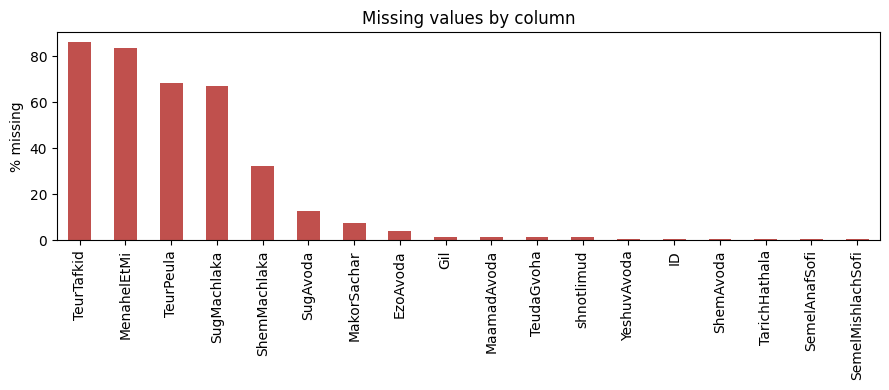

In [6]:
miss = (df.isnull().mean()*100).sort_values(ascending=False)
display(miss.round(1).to_frame("missing_%"))
plt.figure(figsize=(9,4))
miss.plot(kind="bar", color="#c0504d")
plt.ylabel("% missing"); plt.title("Missing values by column"); plt.tight_layout(); plt.show()

### 1.2 Target structure — `SemelMishlachSofi`
ISCO‑style codes are **hierarchical**: the 1st digit is the *major group*, 1st two digits the
*sub‑major group*, etc. Many classes with few examples each ⇒ retrieval/few‑shot beats a
flat classifier, and partial (1–2 digit) accuracy is operationally meaningful.

Rows: 201 | non-null targets: 200 | unique codes: 62

Classes with a single example: 25 / 62  (40% singletons)
Median examples per class: 2


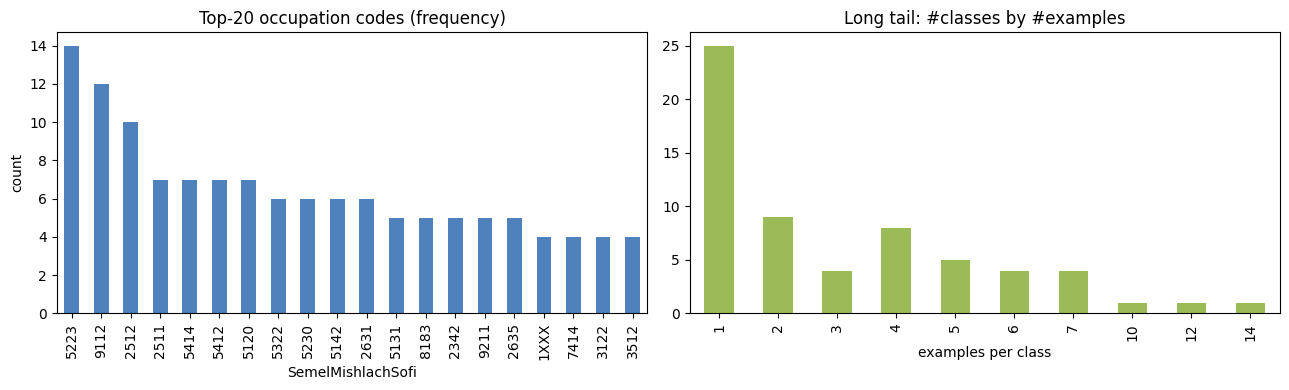


Major-group (1st digit) distribution:


,count
SemelMishlachSofi,
1,8
2,57
3,21
4,8
5,61
7,12
8,8
9,21
X,4


In [7]:
y_raw = df[TARGET].astype("string").str.strip()
print("Rows:", len(df), "| non-null targets:", y_raw.notna().sum(),
      "| unique codes:", y_raw.nunique())
vc = y_raw.value_counts()
print(f"\nClasses with a single example: {(vc==1).sum()} / {vc.size}  "
      f"({100*(vc==1).mean():.0f}% singletons)")
print("Median examples per class:", int(vc.median()))

fig,ax=plt.subplots(1,2,figsize=(13,4))
vc.head(20).plot(kind="bar", ax=ax[0], color="#4f81bd")
ax[0].set_title("Top-20 occupation codes (frequency)"); ax[0].set_ylabel("count")
vc.value_counts().sort_index().plot(kind="bar", ax=ax[1], color="#9bbb59")
ax[1].set_title("Long tail: #classes by #examples"); ax[1].set_xlabel("examples per class")
plt.tight_layout(); plt.show()

# major-group (1st digit) distribution
major = y_raw.dropna().str[0]
print("\nMajor-group (1st digit) distribution:")
display(major.value_counts().sort_index().to_frame("count"))

### 1.3 Noise & data‑quality issues
The three issues the assignment flags explicitly.

In [8]:
# (a) "כנ"ל" ditto placeholders ("same as above") — non-informative tokens
GERSH = str.maketrans({'\u05F4':'"','\u05F3':"'",'”':'"','’':"'","״":'"',"׳":"'"})
def _norm(s):
    if pd.isna(s): return ""
    s=str(s).translate(GERSH).strip()
    s=re.sub(r"[\u0591-\u05C7]","",s)     # strip niqqud/cantillation
    return re.sub(r"\s+"," ",s)
DITTO = {'כנ"ל','כנל',"כנ'ל"}
def _is_ditto(s): return _norm(s) in DITTO

ditto = {c:int(df[c].map(_is_ditto).sum()) for c in TEXT_FIELDS if c in df}
print('Count of "כנ"ל" (ditto) per field:'); display(pd.Series(ditto).sort_values(ascending=False).to_frame("ditto"))

# (b) uncodable records: codes containing X (target) / XXXX (industry)
x_tgt = y_raw.str.upper().str.contains("X", na=False)
x_ind = df[INDUSTRY].astype("string").str.upper().str.contains("X", na=False)
print(f'\nUncodable target codes (contain "X"): {int(x_tgt.sum())} '
      f'({100*x_tgt.mean():.1f}%)')
print(f'Uncodable industry codes (XXXX)       : {int(x_ind.sum())} '
      f'({100*x_ind.mean():.1f}%)')

# (c) repeated / partial submissions: duplicate IDs and near-duplicate records
dup_ids = int(df["ID"].duplicated(keep=False).sum())
dup_rows = int(df.duplicated(subset=[c for c in TEXT_FIELDS if c in df], keep=False).sum())
print(f"\nDuplicate IDs: {dup_ids} | rows with identical free-text content: {dup_rows}")
print("Note: ~10% of manual labels are expected to be wrong (stated label noise).")

Count of "כנ"ל" (ditto) per field:


,ditto
TeurPeula,12
SugMachlaka,8
TeurTafkid,4
EzoAvoda,0
ShemAvoda,0
SugAvoda,0
ShemMachlaka,0
YeshuvAvoda,0



Uncodable target codes (contain "X"): 9 (4.5%)
Uncodable industry codes (XXXX)       : 9 (4.5%)

Duplicate IDs: 0 | rows with identical free-text content: 24
Note: ~10% of manual labels are expected to be wrong (stated label noise).


### 1.4 Free‑text coverage & vocabulary
How much signal each text field carries, and the most frequent tokens (Hebrew renders
correctly in tables, so we tabulate rather than plot).

In [9]:
txt_cov = pd.DataFrame({
    "non_null_%": [round(100*df[c].notna().mean(),1) for c in TEXT_FIELDS if c in df],
    "uniq_values":[df[c].nunique() for c in TEXT_FIELDS if c in df],
    "avg_chars":  [round(df[c].dropna().astype(str).str.len().mean(),1) for c in TEXT_FIELDS if c in df],
}, index=[c for c in TEXT_FIELDS if c in df])
display(txt_cov)

from collections import Counter
def _tok(s): return re.findall(r"[\u05D0-\u05EAA-Za-z0-9']+", _norm(s))
toks=Counter()
for c in ["EzoAvoda","TeurPeula","SugAvoda","ShemMachlaka"]:
    if c in df:
        for v in df[c].dropna(): toks.update(_tok(v))
print("Top 20 tokens across key text fields:")
display(pd.DataFrame(toks.most_common(20), columns=["token","count"]))

,non_null_%,uniq_values,avg_chars
EzoAvoda,96.0,84,14.5
TeurPeula,31.8,32,19.4
TeurTafkid,13.9,16,9.6
ShemAvoda,99.5,82,9.5
SugAvoda,87.1,78,11.1
ShemMachlaka,67.7,61,7.7
SugMachlaka,32.8,35,10.9
YeshuvAvoda,99.5,21,6.0


Top 20 tokens across key text fields:


,token,count
0,של,28
1,תוכנה,25
2,פיתוח,25
3,עובד,21
4,ייצור,20
5,בית,19
6,תמיכה,17
7,ספר,15
8,מטפל,14
9,ל,14


### 1.5 Coded / numeric fields
`MenahelEtMi`, `MaamadAvoda`, `MakorSachar`, `TeudaGvoha` look numeric but are **categorical codes**, so an ordinary (Pearson) correlation on them is meaningless — the numbers are labels, not quantities. `Gil` / `shnotlimud` are the only genuine numerics. We inspect their distributions here and measure the *right* kind of association in §1.6.

In [10]:
for c in CAT_FIELDS:
    if c in df:
        print(f"{c}:", df[c].value_counts(dropna=False).sort_index().to_dict())
display(df[[c for c in NUM_FIELDS if c in df]].describe().round(1))

MenahelEtMi: {1.0: 8, 1.7249999999999999: 1, 2.0: 11, 3.0: 13, nan: 168}
MaamadAvoda: {1.0: 177, 2.0: 1, 4.0: 10, 6.0: 10, nan: 3}
MakorSachar: {1.0: 144, 2.0: 26, 3.0: 11, 4.0: 5, nan: 15}
TeudaGvoha: {1.0: 3, 2.0: 12, 3.0: 57, 4.0: 58, 5.0: 25, 6.0: 39, 7.0: 4, nan: 3}


,shnotlimud,Gil
count,198.0,198.0
mean,14.3,39.5
std,2.9,12.6
min,7.0,22.0
25%,12.0,31.0
50%,14.0,37.0
75%,16.0,46.0
max,22.0,78.0


### 1.6 Correlation & association analysis
The assignment data is mostly **categorical** (coded fields + the target code), with only two truly numeric fields. We therefore measure association with two appropriate tools instead of a single misleading Pearson heatmap:

- **Numeric ↔ numeric** (`Gil`, `shnotlimud`): **Pearson** (linear) and **Spearman** (monotonic) correlation.
- **Categorical ↔ categorical** (the coded fields and the target's *major group* = 1st ISCO digit): **Cramér's V**, the standard association measure for nominal variables, in its **bias-corrected** form (Bergsma–Wicher) so small samples don't inflate it. V ranges 0 (no association) → 1 (perfect).

The last table answers the practical question: *which coded fields actually carry signal about the occupation code?* — i.e. which are worth feeding the model as features alongside the free text.

Numeric correlation  shnotlimud ↔ Gil  (n=198):
  Pearson : 0.235
  Spearman: 0.244

Cramér's V association matrix (bias-corrected; 0=none → 1=perfect):


,MenahelEtMi,MaamadAvoda,MakorSachar,TeudaGvoha,MajorGroup
MenahelEtMi,1.00,0.18,0.31,0.36,0.49
MaamadAvoda,0.18,1.00,0.00,0.06,0.34
MakorSachar,0.31,0.00,1.00,0.41,0.30
TeudaGvoha,0.36,0.06,0.41,1.00,0.38
MajorGroup,0.49,0.34,0.30,0.38,1.00


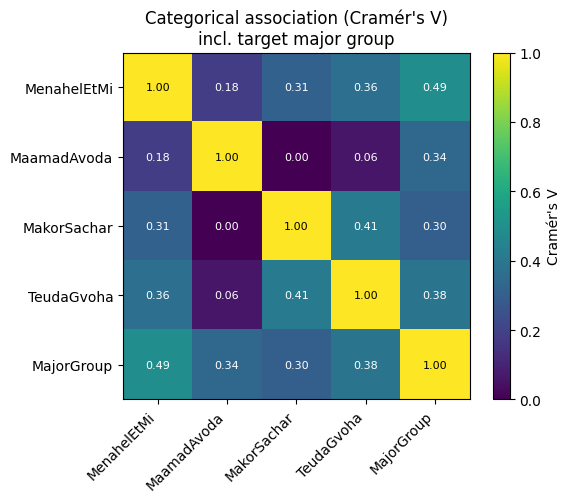


Association of each coded field with the target major group:


,cramers_v
MenahelEtMi,0.490
TeudaGvoha,0.384
MaamadAvoda,0.338
MakorSachar,0.302


In [11]:
from scipy.stats import chi2_contingency, spearmanr, pearsonr

# (a) genuine numerics: Pearson (linear) + Spearman (monotonic) ----------------
num = [c for c in NUM_FIELDS if c in df]
if len(num) >= 2:
    nd = df[num].dropna()
    print(f"Numeric correlation  {num[0]} ↔ {num[1]}  (n={len(nd)}):")
    print(f"  Pearson : {pearsonr(nd[num[0]], nd[num[1]])[0]:.3f}")
    print(f"  Spearman: {spearmanr(nd[num[0]], nd[num[1]]).correlation:.3f}")
else:
    print("Fewer than two numeric fields present — skipping numeric correlation.")

# (b) bias-corrected Cramér's V for categorical association ---------------------
def cramers_v(a, b):
    """Bias-corrected Cramér's V (Bergsma–Wicher) between two categorical series."""
    d = pd.DataFrame({"a": a, "b": b}).dropna()
    if d["a"].nunique() < 2 or d["b"].nunique() < 2:
        return np.nan
    ct = pd.crosstab(d["a"], d["b"])
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.to_numpy().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    phi2c = max(0.0, phi2 - (k - 1) * (r - 1) / (n - 1))     # bias correction
    rc = r - (r - 1) ** 2 / (n - 1)
    kc = k - (k - 1) ** 2 / (n - 1)
    denom = min(kc - 1, rc - 1)
    return float(np.sqrt(phi2c / denom)) if denom > 0 else np.nan

# include the target's major group (1st ISCO digit) so we can see what predicts it
tmp = df.copy()
tmp["MajorGroup"] = df[TARGET].astype("string").str.strip().str[0]
assoc_fields = [c for c in CAT_FIELDS if c in df] + ["MajorGroup"]

V = pd.DataFrame(index=assoc_fields, columns=assoc_fields, dtype=float)
for i in assoc_fields:
    for j in assoc_fields:
        V.loc[i, j] = 1.0 if i == j else cramers_v(tmp[i], tmp[j])

print("\nCramér's V association matrix (bias-corrected; 0=none → 1=perfect):")
display(V.round(2))

plt.figure(figsize=(6, 5))
plt.imshow(V.astype(float).to_numpy(), vmin=0, vmax=1, cmap="viridis")
plt.colorbar(label="Cramér's V")
plt.xticks(range(len(assoc_fields)), assoc_fields, rotation=45, ha="right")
plt.yticks(range(len(assoc_fields)), assoc_fields)
for i in range(len(assoc_fields)):
    for j in range(len(assoc_fields)):
        v = V.iloc[i, j]
        if pd.notna(v):
            plt.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                     color="white" if v < 0.6 else "black")
plt.title("Categorical association (Cramér's V)\nincl. target major group")
plt.tight_layout(); plt.show()

# (c) which coded field is most associated with the occupation code? -----------
target_assoc = (V["MajorGroup"].drop("MajorGroup")
                .sort_values(ascending=False).round(3))
print("\nAssociation of each coded field with the target major group:")
display(target_assoc.to_frame("cramers_v"))

### 1.7 EDA takeaways → modeling implications
- **Free text in Hebrew is the real signal** → build one tagged "document" per record; use a
  Hebrew-aware representation (char n-grams for the lexical model; a Hebrew bi-encoder for the
  semantic model).
- **Long tail / near few-shot** → a flat classifier struggles; **retrieval (nearest already-coded
  records)** is the natural fit and mirrors real computer-assisted coding.
- **Weak coded-field association** → the Cramér's V matrix (§1.6) shows the coded categorical
  fields are only weakly associated with the target's major group, confirming they are at best
  secondary features — the occupation code has to come from the text.
- **Noise**: resolve `כנ"ל` to the previous field; treat `X` codes as *uncodable* (exclude from the
  training pool, report separately); de-duplicate repeated submissions.
- **Evaluation** must use macro-F1 (imbalance) **and** hierarchical (1–2 digit) accuracy, plus
  top-k (a coder is happy with a short shortlist).

### 1.8 ISCO-08 occupation codebook
Tier 2 retrieves against the **official ISCO-08 codebook** (one definition per 4-digit code), so we load it here. If the codebook file isn't present, we fall back to a minimal codebook built from the codes that appear in the data — this keeps the whole notebook runnable in Colab without the second file, as the assignment requires.

In [12]:
def load_isco_dictionary():
    """Official ISCO-08 4-digit codebook, or a minimal data-derived fallback."""
    import os
    if os.path.exists(DICTIONARY_PATH):
        dd = pd.read_excel(DICTIONARY_PATH)
        dd["ISCO 08 Code"] = dd["ISCO 08 Code"].astype(str).str.strip()
        four = dd[dd["ISCO 08 Code"].str.match(r"^\d{4}$")].copy()       # 4-digit unit groups
        defn = ("Definition" if "Definition" in four.columns
                else "Title EN" if "Title EN" in four.columns
                else four.columns[1])
        out = (four[["ISCO 08 Code", defn]]
               .rename(columns={defn: "Definition"})
               .reset_index(drop=True))
        print(f"Loaded ISCO-08 codebook: {len(out)} four-digit unit groups.")
        return out
    # fallback: synthesize a codebook from labels present in the data
    print("ISCO codebook file not found -> building a minimal codebook from data codes.")
    seen = df[TARGET].astype("string").str.strip().dropna()
    seen = sorted({c for c in seen if re.fullmatch(r"\d{4}", str(c))})
    return pd.DataFrame({"ISCO 08 Code": seen,
                         "Definition": [f"קוד משלח יד {c}" for c in seen]})

df_isco_4digit = load_isco_dictionary()
display(df_isco_4digit.head())

Loaded ISCO-08 codebook: 433 four-digit unit groups.


,ISCO 08 Code,Definition
0,1111,"Legislators determine, formulate, and direct policies of..."
1,1112,Senior government officials advise governments on policy...
2,1113,Traditional chiefs and heads of villages perform a varie...
3,1114,Senior officials of special-interest organizations deter...
4,1120,Managing directors and chief executives formulate and re...


## 2. Shared preprocessing, split & evaluation
One reusable text builder, target cleaner, retrieval pool, and a single `evaluate()` used by
all three model tiers (apples‑to‑apples).

In [13]:
def build_text(row):
    """Concatenate free-text fields into one tagged Hebrew document; resolve כנ"ל ditto."""
    parts, prev = [], ""
    for c in TEXT_FIELDS:
        if c not in row.index: continue
        v=_norm(row[c])
        if not v: continue
        if _is_ditto(v): v=prev
        if not v: continue
        parts.append(f"{FIELD_HE.get(c,c)}: {v}"); prev=v
    return " | ".join(parts)

def clean_target(v):
    s=_norm(v).upper()
    return s if s else None

data = df.copy()
data["text"] = data.apply(build_text, axis=1)
data["y"]    = data[TARGET].map(clean_target)
data = data[data["y"].notna() & (data["text"].str.len()>0)].copy()

# uncodable (X) rows: keep for reporting, exclude from trainable pool
data["uncodable"] = data["y"].str.contains("X")
trainable = data[~data["uncodable"]].drop_duplicates(subset=["text","y"]).reset_index(drop=True)
print(f"Total usable: {len(data)} | trainable (codable, de-duped): {len(trainable)} | "
      f"uncodable held out: {int(data['uncodable'].sum())}")

# train/test split (stratification impossible with singletons -> simple random split)
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(trainable, test_size=0.25, random_state=RANDOM_STATE)
train_df=train_df.reset_index(drop=True); test_df=test_df.reset_index(drop=True)
POOL_TEXT, POOL_Y = train_df["text"].tolist(), train_df["y"].tolist()   # retrieval memory
TEST_TEXT, TEST_Y = test_df["text"].tolist(),  test_df["y"].tolist()
print("train/pool:", len(train_df), "| test:", len(test_df))

Total usable: 200 | trainable (codable, de-duped): 179 | uncodable held out: 9
train/pool: 134 | test: 45


In [14]:
from sklearn.metrics import accuracy_score, f1_score

def _hier(pred, truth, d):
    return float(np.mean([str(p)[:d]==str(t)[:d] for p,t in zip(pred,truth)]))
def _topk(cands, truth, k):
    return float(np.mean([t in list(c)[:k] for c,t in zip(cands,truth)]))

RESULTS=[]
def evaluate(name, pred, truth, cands=None, store=True):
    """Unified metrics for every tier. `cands` = ranked candidate lists (optional)."""
    r={"model":name,
       "top1":   accuracy_score(truth,pred),
       "macroF1":f1_score(truth,pred,average="macro",zero_division=0),
       "hier_1digit":_hier(pred,truth,1),
       "hier_2digit":_hier(pred,truth,2)}
    if cands is not None:
        r["top3"]=_topk(cands,truth,3); r["top5"]=_topk(cands,truth,5); r["top20"]=_topk(cands,truth,20)
    if store: RESULTS.append(r)
    print(f"[{name}]  top1={r['top1']:.3f}  macroF1={r['macroF1']:.3f}  "
          f"hier1={r['hier_1digit']:.3f}" + (f"  top5={r.get('top5',float('nan')):.3f}, top20={r.get('top20',float('nan')):.3f}" if cands is not None else ""))
    return r

def knn_vote(scores, labels, k):
    """Similarity-weighted vote -> ranked unique candidate codes."""
    idx=np.argsort(-np.asarray(scores))[:k]
    from collections import defaultdict
    agg=defaultdict(float)
    for i in idx: agg[str(labels[i])]+=float(scores[i])+1e-9
    return [c for c,_ in sorted(agg.items(), key=lambda kv:-kv[1])], idx

## 3. Tier 1 — Classic / lexical models
Two complementary baselines:
1. **TF‑IDF (word + char n‑grams) → Logistic Regression.** Char n‑grams matter for Hebrew
   morphology (prefixes/suffixes, no lemmatization needed). A flat classifier.
2. **BM25 k‑NN coder.** Pure‑lexical retrieval: find the most similar already‑coded records and
   vote. Dependency‑free pure‑NumPy BM25 — and a direct lexical analogue of the Tier‑2 bi‑encoder.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack

word = TfidfVectorizer(analyzer="word", ngram_range=(1,2), min_df=1, sublinear_tf=True)
char = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5), min_df=1, sublinear_tf=True)
Xtr = hstack([word.fit_transform(POOL_TEXT), char.fit_transform(POOL_TEXT)]).tocsr()
Xte = hstack([word.transform(TEST_TEXT),    char.transform(TEST_TEXT)]).tocsr()

clf = LogisticRegression(max_iter=3000, class_weight="balanced")
clf.fit(Xtr, POOL_Y)
proba = clf.predict_proba(Xte); classes=np.array(clf.classes_)
order = np.argsort(-proba, axis=1)
pred_tfidf  = classes[order[:,0]]
cands_tfidf = [classes[o].tolist() for o in order]
evaluate("TF-IDF + LogReg", pred_tfidf, TEST_Y, cands_tfidf)

[TF-IDF + LogReg]  top1=0.778  macroF1=0.578  hier1=0.800  top5=0.778, top20=0.778


{'model': 'TF-IDF + LogReg',
 'top1': 0.7777777777777778,
 'macroF1': 0.5781512605042016,
 'hier_1digit': 0.8,
 'hier_2digit': 0.7777777777777778,
 'top3': 0.7777777777777778,
 'top5': 0.7777777777777778,
 'top20': 0.7777777777777778}

In [16]:
class BM25:
    """Minimal Okapi BM25 over a fixed corpus (pure NumPy, no external deps)."""
    def __init__(self, docs, k1=1.5, b=0.75):
        self.docs=[_tok(d) for d in docs]; self.k1,self.b=k1,b
        self.N=len(self.docs); self.dl=np.array([len(d) or 1 for d in self.docs])
        self.avgdl=self.dl.mean()
        from collections import Counter, defaultdict
        self.tf=[Counter(d) for d in self.docs]
        dfq=defaultdict(int)
        for d in self.docs:
            for t in set(d): dfq[t]+=1
        self.idf={t:np.log(1+(self.N-n+0.5)/(n+0.5)) for t,n in dfq.items()}
    def scores(self, query):
        q=_tok(query); s=np.zeros(self.N)
        for t in q:
            idf=self.idf.get(t)
            if idf is None: continue
            for i in range(self.N):
                f=self.tf[i].get(t,0)
                if f: s[i]+=idf*f*(self.k1+1)/(f+self.k1*(1-self.b+self.b*self.dl[i]/self.avgdl))
        return s

bm = BM25(POOL_TEXT)
pred_bm, cands_bm = [], []
for q in TEST_TEXT:
    ranked,_ = knn_vote(bm.scores(q), POOL_Y, k=5)
    pred_bm.append(ranked[0] if ranked else POOL_Y[0]); cands_bm.append(ranked)
evaluate("BM25 kNN (k=5)", pred_bm, TEST_Y, cands_bm)

# qualitative example
i=0
print("\nExample query:\n ", TEST_TEXT[i][:140])
print(" true:", TEST_Y[i], "| BM25 candidates:", cands_bm[i][:5])

[BM25 kNN (k=5)]  top1=0.667  macroF1=0.450  hier1=0.800  top5=0.778, top20=0.778

Example query:
  עיסוק: חשדרנית | מקום עבודה: בית מלון | סוג עסק: אירוח | מחלקה: משק | יישוב: אשקלון
 true: 9112 | BM25 candidates: ['9112', '5120']


In [21]:
from collections import Counter

def find_mistakes(model_name, predictions, true_labels):
    """
    Finds and counts the true codes for which a model made a mistake.
    """
    mistakes = Counter()
    total_mistakes = 0
    for i in range(len(true_labels)):
        if predictions[i] != true_labels[i]:
            mistakes[true_labels[i]] += 1
            total_mistakes += 1

    print(f"\n--- Top 10 mistakes for {model_name} (Total mistakes: {total_mistakes}) ---")
    if mistakes:
        for code, count in mistakes.most_common(10):
            print(f"Code: {code}, Mistakes: {count}")
    else:
        print("No mistakes found (perfect prediction or empty set).")
    return mistakes

# Analyze mistakes for TF-IDF + LogReg
# pred_tfidf and TEST_Y are available in the kernel state
find_mistakes("TF-IDF + LogReg", pred_tfidf, TEST_Y)

# Analyze mistakes for BM25 kNN (k=5)
# pred_bm and TEST_Y are available in the kernel state
find_mistakes("BM25 kNN (k=5)", pred_bm, TEST_Y)


--- Top 10 mistakes for TF-IDF + LogReg (Total mistakes: 10) ---
Code: 9412, Mistakes: 2
Code: 2431, Mistakes: 1
Code: 1330, Mistakes: 1
Code: 3354, Mistakes: 1
Code: 5153, Mistakes: 1
Code: 3211, Mistakes: 1
Code: 1212, Mistakes: 1
Code: 3312, Mistakes: 1
Code: 7126, Mistakes: 1

--- Top 10 mistakes for BM25 kNN (k=5) (Total mistakes: 15) ---
Code: 7414, Mistakes: 2
Code: 9412, Mistakes: 2
Code: 3513, Mistakes: 1
Code: 2431, Mistakes: 1
Code: 1330, Mistakes: 1
Code: 9329, Mistakes: 1
Code: 3354, Mistakes: 1
Code: 5153, Mistakes: 1
Code: 3211, Mistakes: 1
Code: 1212, Mistakes: 1


Counter({'3513': 1,
         '2431': 1,
         '1330': 1,
         '9329': 1,
         '7414': 2,
         '3354': 1,
         '5153': 1,
         '3211': 1,
         '1212': 1,
         '3312': 1,
         '7126': 1,
         '9412': 2,
         '2514': 1})

## 4. Tier 2 — Semantic bi‑encoder retrieval (NeoDictaBERT)
A lexical match fails when wording differs ("מטפל בקשיש" vs "סיעוד לקשישים"). We embed every
record with **`dicta-il/neodictabert-bilingual-embed`** (a Hebrew/English sentence‑transformer,
768‑dim) and retrieve the nearest already‑coded records by cosine similarity, then vote.

The model card uses an asymmetric `"query: "` prefix for queries — we follow that. If the model
can't be downloaded, we fall back to a smaller multilingual encoder so the cell still runs.

**What we retrieve against.** Rather than matching a survey to other *surveys*, we match each survey description to the **ISCO codebook definitions** and let the nearest definitions vote for a code. This grounds every suggestion in the official catalogue and scales to all codes, including ones with no training example yet.

**Implementation note.** We encode with plain `encoder.encode(...)` (rather than `encode_query`/`encode_document`) because those convenience methods aren't available on every model/library version — the fallback encoder included — and we apply the model card's asymmetric `"query: "` prefix manually on the query side. This keeps the cell crash-free in Colab.

In [17]:
def load_encoder():
    from sentence_transformers import SentenceTransformer
    try:
        m = SentenceTransformer("intfloat/multilingual-e5-large") #SentenceTransformer(EMBED_MODEL, trust_remote_code=True)
        print("Loaded encoder:", EMBED_MODEL)
        return m, True
    except Exception as e:
        print("Primary encoder unavailable (", str(e)[:80], "...) -> fallback:", EMBED_FALLBACK)
        return SentenceTransformer(EMBED_FALLBACK), False

encoder, is_dicta = load_encoder()

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/160k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Loaded encoder: dicta-il/neodictabert-bilingual-embed


In [18]:
# Encode the codebook (documents) and the test queries ONCE, with hygiene checks.
def _as_query(texts):
    # dicta uses an asymmetric "query: " prefix on the query side only
    return ["query: " + t for t in texts] if is_dicta else list(texts)

defs  = [(str(d).strip() or "לא ידוע") for d in df_isco_4digit["Definition"].tolist()]
codes = df_isco_4digit["ISCO 08 Code"].astype(str).str.strip().to_numpy()
TEST_TEXT = [(t.strip() or "לא ידוע") for t in TEST_TEXT]     # guard empty queries

def_emb  = encoder.encode(defs, normalize_embeddings=True, batch_size=32, show_progress_bar=True)
test_emb = encoder.encode(_as_query(TEST_TEXT), normalize_embeddings=True,
                          batch_size=32, show_progress_bar=True)

assert not np.isnan(def_emb).any() and not np.isnan(test_emb).any(), "NaN in embeddings"
print(f"Encoded {len(defs)} codebook definitions + {len(test_emb)} queries "
      f"-> {def_emb.shape[1]}-dim vectors.")
print("Codebook coverage of test labels:",
      len(set(map(str, TEST_Y)) & set(map(str, codes))), "/", len(set(TEST_Y)))

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Encoded 433 codebook definitions + 45 queries -> 1024-dim vectors.
Codebook coverage of test labels: 29 / 30


In [19]:
from sentence_transformers.util import semantic_search

# Index = codebook: `codes` (one ISCO code per row) + `def_emb` (encoded definitions).
# `test_emb` = queries encoded with the "query: " prefix.
# Returns, per query, a list of {"corpus_id": i, "score": s} sorted by score desc.
hits = semantic_search(test_emb, def_emb, top_k=20)   # cosine (embeddings are normalized)

pred_bi, cands_bi, shortlist = [], [], []
for r, query_hits in enumerate(hits):
    ranked, seen, payload = [], set(), []
    for h in query_hits:
        i = h["corpus_id"]
        c = str(codes[i])
        if c in seen:                       # guard if a code spans multiple rows
            continue
        seen.add(c)
        ranked.append(c)
        if len(payload) < 10:
            payload.append({"code": c, "definition": defs[i],
                            "sim": round(float(h["score"]), 3)})
    pred_bi.append(ranked[0] if ranked else str(codes[0]))
    cands_bi.append(ranked)
    shortlist.append(payload)

evaluate(f"Bi-encoder vs codebook (k={TOPK})", pred_bi, TEST_Y, cands_bi)
print("\nExample shortlist for the LLM:")
print(" query:", TEST_TEXT[1][:120])
print(" code:", TEST_Y[1])
for p in shortlist[1]:
    print("  ", p["code"], p["sim"], "|", p["definition"][:60])

[Bi-encoder vs codebook (k=8)]  top1=0.267  macroF1=0.159  hier1=0.489  top5=0.644, top20=0.733

Example shortlist for the LLM:
 query: עיסוק: קוסמטיקאית | מקום עבודה: קוסמטיקאית עצמאית | יישוב: בת ים
 code: 5142
   5142 0.798 | Beauticians and related workers, give facial and body beauty
   5322 0.773 | Home-based personal care workers provide routine personal ca
   5329 0.772 | This unit group covers providers of routine health and perso
   5141 0.771 | Hairdressers cut, style, colour, straighten and permanently 
   9129 0.771 | This unit group includes cleaning workers not classified els
   5221 0.769 | Shopkeepers operate small retail shops either independently 
   9622 0.766 | Odd job persons clean, paint and maintain buildings, grounds
   5249 0.762 | This unit group includes sales workers not classified elsewh
   5311 0.762 | Child care workers provide care and supervision for children
   5152 0.762 | Domestic housekeepers organize, supervise and carry out hous


### 4.1 Hybrid retrieval — fuse lexical + semantic (RRF)
Lexical (BM25 over the coded survey pool) and semantic (bi-encoder over the codebook) make different mistakes. We merge their ranked candidate lists with **Reciprocal Rank Fusion** — a score-free combiner that only uses each item's *rank* — to get a single, more robust shortlist to hand to the LLM.

In [20]:
# --- per-query ranked candidate codes from each retriever ---
def bm25_codes(query, k=20):
    ranked, _ = knn_vote(bm.scores(query), POOL_Y, k=k)   # lexical: vote over survey pool
    return ranked

bi_hits = semantic_search(test_emb, def_emb, top_k=20)    # semantic: over codebook defs
def bi_codes(r):
    seen, ranked = set(), []
    for h in bi_hits[r]:
        c = str(codes[h["corpus_id"]])
        if c not in seen:
            seen.add(c); ranked.append(c)
    return ranked

# --- Reciprocal Rank Fusion: merge ranked lists, ignore score scales ---
def rrf(ranked_lists, k=60, top_n=20):
    score = defaultdict(float)
    for lst in ranked_lists:
        for rank, code in enumerate(lst):
            score[code] += 1.0 / (k + rank)               # earlier rank -> bigger contribution
    return [c for c, _ in sorted(score.items(), key=lambda kv: -kv[1])][:top_n]

In [22]:
def_by_code = {str(c): d for c, d in zip(codes, defs)}    # codebook definition per code
ex_by_code = {}
for t, y in zip(POOL_TEXT, POOL_Y):                       # one representative survey per code
    ex_by_code.setdefault(str(y), t)

pred_fused, cands_fused, shortlist = [], [], []
for r in range(len(TEST_TEXT)):
    fused = rrf([bi_codes(r), bm25_codes(TEST_TEXT[r], k=20)], top_n=20)
    pred_fused.append(fused[0] if fused else str(codes[0]))
    cands_fused.append(fused)
    shortlist.append([
        {"code": c,
         "definition": def_by_code.get(c, ""),
         "example":    ex_by_code.get(c, "")}
        for c in fused
    ])

evaluate(f"Hybrid (BM25 + bi-encoder, RRF) (k={TOPK})", pred_fused, TEST_Y, cands_fused)

[Hybrid (BM25 + bi-encoder, RRF) (k=8)]  top1=0.489  macroF1=0.282  hier1=0.644  top5=0.822, top20=0.889


{'model': 'Hybrid (BM25 + bi-encoder, RRF) (k=8)',
 'top1': 0.4888888888888889,
 'macroF1': 0.2816666666666667,
 'hier_1digit': 0.6444444444444445,
 'hier_2digit': 0.6,
 'top3': 0.8,
 'top5': 0.8222222222222222,
 'top20': 0.8888888888888888}

## 5. Tier 3 — LLM final decision over the candidate shortlist (Ollama)
The bi‑encoder narrows thousands of codes to a handful. A **Hebrew‑capable LLM run locally via
Ollama** then reads the survey text + the candidate codes (each with an example) and picks the
best one with a short justification — a *retrieve‑and‑rerank / LLM‑as‑judge* step. Running
locally matters for CBS: **survey data never leaves the premises**.

**Model choice.** Set `OLLAMA_MODEL` to a strong Hebrew model. Recommended for production:
**DictaLM‑3.0** (Dicta's sovereign Hebrew LLM — same group as the embedder) via a custom
Modelfile; good general alternatives on the Ollama registry are `aya-expanse` (Cohere,
explicitly multilingual) and larger `gemma3`. We default to a small `gemma3:4b` so it pulls
quickly in Colab.

**Robustness.** Everything is wrapped: if Ollama isn't installed/reachable, each record falls
back to the bi‑encoder's top‑1, so the notebook still completes.

In [25]:
# One-time Ollama setup, fully wrapped: if anything fails, OLLAMA_OK stays False and
# every record falls back to the bi-encoder's top-1, so the notebook still completes.
import subprocess, time, shutil, requests

def setup_ollama(model=OLLAMA_MODEL, host=OLLAMA_HOST):
    try:
        if shutil.which("ollama") is None:
            print("Installing Ollama ...")
            subprocess.run("curl -fsSL https://ollama.com/install.sh | sh",
                           shell=True, timeout=600)
        # launch the server from Python so it persists across cells
        subprocess.Popen(["ollama", "serve"],
                         stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        for _ in range(20):                                  # wait until it answers
            try:
                if requests.get(f"{host}/api/tags", timeout=2).status_code == 200:
                    break
            except Exception:
                time.sleep(1)
        print(f"Pulling {model} (first run only, multi-GB) ...")
        subprocess.run(["ollama", "pull", model], timeout=1800, check=True)
        print("Ollama ready.")
        return True
    except Exception as e:
        print("Ollama unavailable:", str(e)[:120], "-> using bi-encoder fallback.")
        return False

OLLAMA_OK = setup_ollama()

Pulling gemma3:4b (first run only, multi-GB) ...
Ollama ready.


In [26]:
import json, re
SYSTEM = ("אתה סמלן מקצועי בלשכה המרכזית לסטטיסטיקה. תפקידך לבחור את סמל משלח היד "
          "(ISCO) המתאים ביותר לתיאור העיסוק, מתוך רשימת מועמדים נתונה בלבד.")

def build_llm_prompt(query_text, payload):
    """Build the Hebrew judge prompt. Each candidate carries either a codebook
    `definition` or a representative `example` survey — we show whichever exists."""
    cand_codes = [p["code"] for p in payload]
    lines = []
    for i, p in enumerate(payload):
        ev = p.get("definition") or p.get("example") or ""
        tag = "הגדרה" if p.get("definition") else "דוגמה"
        lines.append(f'{i+1}. סמל {p["code"]} — {tag}: "{ev[:200]}"')
    user = (f"תיאור העיסוק לסיווג:\n{query_text}\n\n"
            f"מועמדים אפשריים:\n" + "\n".join(lines) +
            f'\n\nבחר בדיוק סמל אחד מתוך הרשימה. החזר JSON תקין בלבד:\n'
            f'{{"code": "<הסמל>", "reason": "<נימוק קצר>"}}')
    return user, cand_codes

def call_ollama(user, system=SYSTEM, model=OLLAMA_MODEL, host=OLLAMA_HOST, timeout=120):
    """Return model text, or None on any failure (caller handles fallback)."""
    try:
        resp = requests.post(f"{host}/api/chat", timeout=timeout, json={
            "model": model, "stream": False, "options": {"temperature": 0},
            "messages": [{"role": "system", "content": system},
                         {"role": "user", "content": user}]})
        resp.raise_for_status()
        return resp.json()["message"]["content"]
    except Exception:
        return None

def parse_choice(txt, cand_codes, fallback):
    """Extract a valid candidate code from the model's reply, else fall back."""
    if txt:
        m = re.search(r"\{.*\}", txt, re.S)             # first JSON object
        if m:
            try:
                obj = json.loads(m.group(0))
                code = str(obj.get("code", "")).strip().upper()
                if code in cand_codes:
                    return code, obj.get("reason", "")
            except Exception:
                pass
        for c in cand_codes:                            # any candidate appearing verbatim
            if c in txt:
                return c, "matched-in-text"
    return fallback, "fallback:bi-encoder-top1"

In [27]:
# Run the LLM judge on a sample of the test set (kept small for runtime).
N_LLM = min(20, len(TEST_TEXT))
pred_llm = list(pred_bi)        # start from bi-encoder preds; override the sample
used_llm = 0
for r in range(N_LLM):
    payload = shortlist[r]      # hybrid RRF shortlist (code / definition / example)
    if not payload:
        continue
    user, cand_codes = build_llm_prompt(TEST_TEXT[r], payload)
    raw = call_ollama(user) if OLLAMA_OK else None
    choice, reason = parse_choice(raw, cand_codes, fallback=pred_bi[r])
    pred_llm[r] = choice
    used_llm += (raw is not None)
    if r < 3:
        print(f"\nquery: {TEST_TEXT[r][:90]}")
        print(f"  candidates: {cand_codes}")
        print(f"  LLM choice: {choice}  ({reason[:60]})  | true: {TEST_Y[r]}")

print(f"\nLLM answered {used_llm}/{N_LLM} (rest used fallback).")
evaluate(f"Bi-encoder + LLM rerank (n={N_LLM})", pred_llm, TEST_Y, store=True)


query: עיסוק: חשדרנית | מקום עבודה: בית מלון | סוג עסק: אירוח | מחלקה: משק | יישוב: אשקלון
  candidates: ['5120', '1411', '9112', '4226', '5414', '5152', '5311', '1345', '4224', '5230', '5151', '5223', '4221', '2511', '8160', '2131', '9412', '9211', '1431', '2142']
  LLM choice: 1411  (fallback:bi-encoder-top1)  | true: 9112

query: עיסוק: קוסמטיקאית | מקום עבודה: קוסמטיקאית עצמאית | יישוב: בת ים
  candidates: ['5142', '5322', '2631', '5329', '2514', '5141', '2330', '9129', '7413', '5221', '2511', '9622', '5120', '5249', '5230', '5311', '5412', '5152', '5419', '5169']
  LLM choice: 5142  (fallback:bi-encoder-top1)  | true: 5142

query: עיסוק: מתחזק רשת מחשבים | תיאור פעולה: נותן תמיכה לעובדים בבנק ופוטר בעיות תקשורת | תיאור 
  candidates: ['3512', '3513', '4211', '7413', '3514', '2631', '3511', '2511', '2522', '7412', '7422', '7421', '2529', '4313', '7411', '2635', '2412', '3522', '2423', '3413']
  LLM choice: 3512  (fallback:bi-encoder-top1)  | true: 3513

LLM answered 0/20 (rest use

{'model': 'Bi-encoder + LLM rerank (n=20)',
 'top1': 0.26666666666666666,
 'macroF1': 0.15947712418300652,
 'hier_1digit': 0.4888888888888889,
 'hier_2digit': 0.4}


query: עיסוק: חשדרנית | מקום עבודה: בית מלון | סוג עסק: אירוח | מחלקה: משק | יישוב: אשקלון
  candidates: ['1411', '9112', '4226', '5414', '5152', '5120', '4224', '1345', '4221', '5230', '5311', '5223', '5151', '2511', '7319', '2131', '4413', '9211', '1439', '2142']
  LLM choice: 4224  (The description of Hotel receptionists (general) aligns with)  | true: 9112

query: עיסוק: קוסמטיקאית | מקום עבודה: קוסמטיקאית עצמאית | יישוב: בת ים
  candidates: ['5142', '5329', '2631', '9129', '2514', '5322', '2330', '5221', '7413', '5141', '2511', '5169', '5120', '7319', '5230', '9629', '5412', '9622', '5419', '5152']
  LLM choice: 5142  (The definition of this code specifically covers 'Beauticians)  | true: 5142

query: עיסוק: מתחזק רשת מחשבים | תיאור פעולה: נותן תמיכה לעובדים בבנק ופוטר בעיות תקשורת | תיאור
  candidates: ['3512', '3513', '4211', '3511', '2631', '3514', '2511', '2529', '7412', '2522', '7413', '7422', '7421', '4313', '2635', '5329', '2412', '1330', '2423', '3522']
  LLM choice: 3512  (The description of ISCO 3512 – "Information and communicatio)  | true: 3513

LLM answered 19/20 (rest used fallback).
[Bi-encoder + LLM rerank (n=20)]  top1=0.422  macroF1=0.275  hier1=0.622
{'model': 'Bi-encoder + LLM rerank (n=20)',
 'top1': 0.4222222222222222,
 'macroF1': 0.27517730496453896,
 'hier_1digit': 0.6222222222222222,
 'hier_2digit': 0.5555555555555556}

## 6. Results comparison

,top1,macroF1,hier_1digit,hier_2digit,top3,top5,top20
model,,,,,,,
TF-IDF + LogReg,0.778,0.578,0.800,0.778,0.778,0.778,0.778
BM25 kNN (k=5),0.667,0.450,0.800,0.711,0.778,0.778,0.778
Bi-encoder vs codebook (k=8),0.267,0.159,0.489,0.400,0.489,0.644,0.733
"Hybrid (BM25 + bi-encoder, RRF) (k=8)",0.489,0.282,0.644,0.600,0.800,0.822,0.889
Bi-encoder + LLM rerank (n=20),0.267,0.159,0.489,0.400,NaN,NaN,NaN


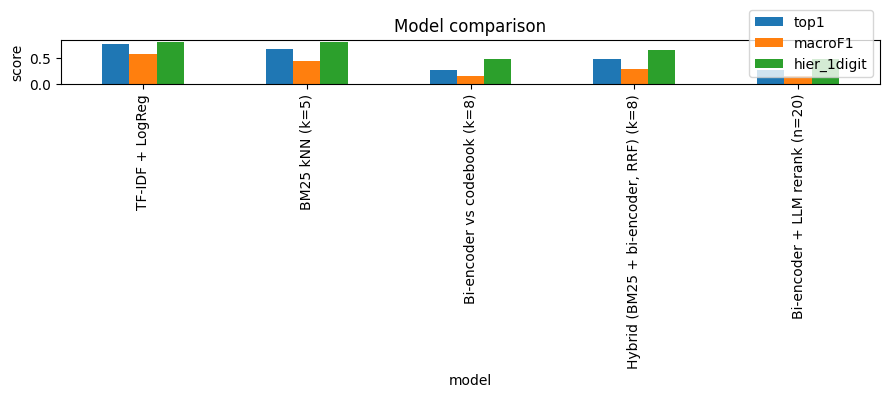

Note: on the small noisy sample absolute numbers are not meaningful (per the assignment) — the architecture and process are the deliverable.


In [28]:
res = pd.DataFrame(RESULTS).set_index("model")
display(res.round(3))
ax = res[[c for c in ["top1","macroF1","hier_1digit"] if c in res]].plot(
        kind="bar", figsize=(9,4))
ax.set_ylabel("score"); ax.set_title("Model comparison"); ax.legend(loc="lower right")
import matplotlib.pyplot as plt; plt.tight_layout(); plt.show()
print("Note: on the small noisy sample absolute numbers are not meaningful "
      "(per the assignment) — the architecture and process are the deliverable.")

## 7. Insights & recommendations for deployment

**Insights from the data**
- The signal lives in a few free‑text fields (`EzoAvoda`, `TeurPeula`, `ShemAvoda`/`SugAvoda`);
  the rarely‑filled and coded fields add little. The task is essentially **Hebrew short‑text
  semantic matching**, not tabular ML.
- The coded categorical fields are only weakly associated with the occupation code (§1.6 Cramér's V), so they cannot carry the classification on their own — the free text is decisive.
- Severe class imbalance + singletons make a flat classifier brittle; **retrieval over previously
  coded records** is both more accurate and naturally explainable (you can show the coder the
  neighbours that drove the suggestion).
- Data quality is the dominant lever: `כנ"ל`, `X`/uncodable, partial and repeated submissions,
  and ~10% label noise all cap achievable accuracy.

**Why retrieve‑and‑rerank**
- Tier 1 (lexical) is a cheap, transparent baseline.
- Tier 2 (bi‑encoder) handles paraphrase/synonymy in Hebrew and scales to the full ISCO catalogue.
- Tier 3 (LLM) resolves the hard, ambiguous cases by reasoning over a *short, grounded* candidate
  list — far safer than letting an LLM free‑generate a code.

**Recommendations for implementation at CBS**
1. **Human‑in‑the‑loop with confidence routing.** Auto‑accept high‑confidence predictions
   (high top‑1 similarity / margin); route low‑confidence and any `X`/uncodable cases to a
   human coder. Track an auto‑coding rate vs. accuracy operating point.
2. **Keep it on‑prem.** The bi‑encoder + a local Ollama LLM run entirely inside CBS — no survey
   data leaves the building.
3. **Fight label noise.** Use the model to surface likely mis‑labels (prediction disagrees with a
   high‑similarity neighbour) for re‑review; this both cleans the gold set and improves the pool.
4. **Active learning & drift.** Newly coded records feed straight back into the retrieval pool;
   periodically review new occupations and monitor distribution drift.
5. **Fine‑tune the bi‑encoder** on (survey‑text → code) pairs once enough verified data exists;
   add a cross‑encoder reranker before the LLM for further gains.
6. **Evaluate hierarchically.** Report 1‑/2‑digit accuracy alongside exact‑match — partial codes
   are still useful to downstream statistics.

---
**GitHub:** _<add your repository link here>_  
**Runtime:** designed to run top‑to‑bottom in Google Colab without crashes (graceful fallbacks at
every advanced stage).